<a href="https://colab.research.google.com/github/bakimuslume/otegezegen-avciligi/blob/main/otegezegen_avciligi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

"""
Ötegezegen (Exoplanet) Avcılığı — Kepler KOI Sınıflandırma Projesi
====================================================================
Veri: NASA Exoplanet Archive - Cumulative KOI Table
      https://exoplanetarchive.ipac.harvard.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=cumulative
      (CSV olarak indir, aynı klasöre "cumulative.csv" adıyla koy)

Bu script iki senaryoyu KARŞILAŞTIRIR:
  A) NAIF senaryo   -> koi_score ve koi_fpflag_* dahil (yapay olarak yüksek başarı)
  B) GERÇEKÇİ senaryo -> bu sızıntılı sütunlar çıkarılmış (asıl zorluk burada)


"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, RocCurveDisplay
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------------------------
# 1) VERİ YÜKLEME
# ---------------------------------------------------------------------------
# NASA arşivinden indirilen CSV'de üst kısımda '#' ile başlayan yorum satırları
# vardır -> comment='#' ile atla.
df = pd.read_csv("cumulative.csv", comment="#")

print("Ham veri boyutu:", df.shape)
print(df["koi_disposition"].value_counts())

# ---------------------------------------------------------------------------
# 2) HEDEF DEĞİŞKEN
# ---------------------------------------------------------------------------
# koi_disposition: CONFIRMED / CANDIDATE / FALSE POSITIVE
# İkili sınıflandırma için önerilen ayrım:
#   pozitif sınıf = CONFIRMED  (gerçek gezegen)
#   negatif sınıf = FALSE POSITIVE
# CANDIDATE satırlarını (henüz doğrulanmamış) modelden ÇIKAR — bunlar "gri alan",
# ne kesin doğru ne kesin yanlış etiket taşıyorlar; dahil etmek gürültü katar.
df = df[df["koi_disposition"].isin(["CONFIRMED", "FALSE POSITIVE"])].copy()
df["target"] = (df["koi_disposition"] == "CONFIRMED").astype(int)

print("\nModelde kullanılacak veri:", df.shape)
print(df["target"].value_counts(normalize=True))

# ---------------------------------------------------------------------------
# 3) FEATURE SETLERİ — İKİ SENARYO
# ---------------------------------------------------------------------------
LEAKY_COLS = ["koi_score", "koi_fpflag_nt", "koi_fpflag_ss", "koi_fpflag_co", "koi_fpflag_ec"]

# Fiziksel/gözlemsel parametreler (gerçekçi senaryonun omurgası)
PHYSICAL_FEATURES = [
    "koi_period",       # yörünge periyodu
    "koi_duration",     # transit süresi
    "koi_depth",        # transit derinliği (ışık kaybı)
    "koi_prad",         # gezegen yarıçapı (tahmini)
    "koi_teq",          # denge sıcaklığı
    "koi_insol",        # gelen ışınım
    "koi_model_snr",    # sinyal/gürültü oranı
    "koi_impact",       # transit çarpma parametresi
    "koi_steff",        # yıldız etkin sıcaklığı
    "koi_slogg",        # yıldız yüzey gravitesi
    "koi_srad",         # yıldız yarıçapı
    "koi_kepmag",       # Kepler manyitüdü (parlaklık)
]

feature_sets = {
    "A_naif_leaky": PHYSICAL_FEATURES + LEAKY_COLS,
    "B_gercekci":   PHYSICAL_FEATURES,
}

# ---------------------------------------------------------------------------
# 4) MODELLER (pipeline: impute -> scale -> model)
# ---------------------------------------------------------------------------
def build_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=400, max_depth=None, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "SVM_RBF": SVC(
        kernel="rbf", C=2.0, gamma="scale", probability=True,
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(n_neighbors=15, weights="distance"),
}

results = []

for scenario_name, cols in feature_sets.items():
    cols = [c for c in cols if c in df.columns]
    X = df[cols]
    y = df["target"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    for model_name, model in models.items():
        pipe = build_pipeline(model)

        # 5-fold stratified cross-validation (eğitim setinde)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        cv_f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test)[:, 1]

        test_f1 = f1_score(y_test, y_pred)
        test_auc = roc_auc_score(y_test, y_proba)

        results.append({
            "senaryo": scenario_name,
            "model": model_name,
            "cv_f1_mean": round(cv_f1.mean(), 4),
            "cv_f1_std": round(cv_f1.std(), 4),
            "test_f1": round(test_f1, 4),
            "test_roc_auc": round(test_auc, 4),
        })

        print(f"\n=== {scenario_name} | {model_name} ===")
        print(classification_report(y_test, y_pred, target_names=["FALSE POSITIVE", "CONFIRMED"]))

        # Confusion matrix kaydet
        fig, ax = plt.subplots(figsize=(4, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred, display_labels=["FALSE POS.", "CONFIRMED"], ax=ax, colorbar=False
        )
        ax.set_title(f"{scenario_name} - {model_name}")
        fig.tight_layout()
        fig.savefig(f"cm_{scenario_name}_{model_name}.png", dpi=150)
        plt.close(fig)

results_df = pd.DataFrame(results)
print("\n\n=== ÖZET TABLO (Medium yazısına doğrudan koyulabilir) ===")
print(results_df.to_string(index=False))
results_df.to_csv("model_results_summary.csv", index=False)

# ---------------------------------------------------------------------------
# 5) FEATURE IMPORTANCE (Random Forest, gerçekçi senaryo)
# ---------------------------------------------------------------------------
cols = [c for c in PHYSICAL_FEATURES if c in df.columns]
X = df[cols]
y = df["target"]

rf_pipe = build_pipeline(RandomForestClassifier(
    n_estimators=400, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
))
rf_pipe.fit(X, y)
importances = pd.Series(
    rf_pipe.named_steps["model"].feature_importances_, index=cols
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("Random Forest - Özellik Önem Sıralaması (Gerçekçi Senaryo)")
fig.tight_layout()
fig.savefig("feature_importance.png", dpi=150)
plt.close(fig)

print("\nBitti. Üretilen dosyalar:")
print(" - model_results_summary.csv")
print(" - cm_*.png (confusion matrix'ler)")
print(" - feature_importance.png")


Ham veri boyutu: (9564, 141)
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2747
CANDIDATE         1978
Name: count, dtype: int64

Modelde kullanılacak veri: (7586, 142)
target
0    0.637886
1    0.362114
Name: proportion, dtype: float64

=== A_naif_leaky | RandomForest ===
                precision    recall  f1-score   support

FALSE POSITIVE       0.99      1.00      1.00       968
     CONFIRMED       1.00      0.99      0.99       550

      accuracy                           1.00      1518
     macro avg       1.00      0.99      1.00      1518
  weighted avg       1.00      1.00      1.00      1518


=== A_naif_leaky | SVM_RBF ===
                precision    recall  f1-score   support

FALSE POSITIVE       0.99      0.99      0.99       968
     CONFIRMED       0.99      0.98      0.99       550

      accuracy                           0.99      1518
     macro avg       0.99      0.99      0.99      1518
  weighted avg       0.99      0.99      0.99      1518


=== 

/tmp/ipykernel_2747/3397893964.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='koi_disposition', y='koi_score', data=df, palette='Set2')


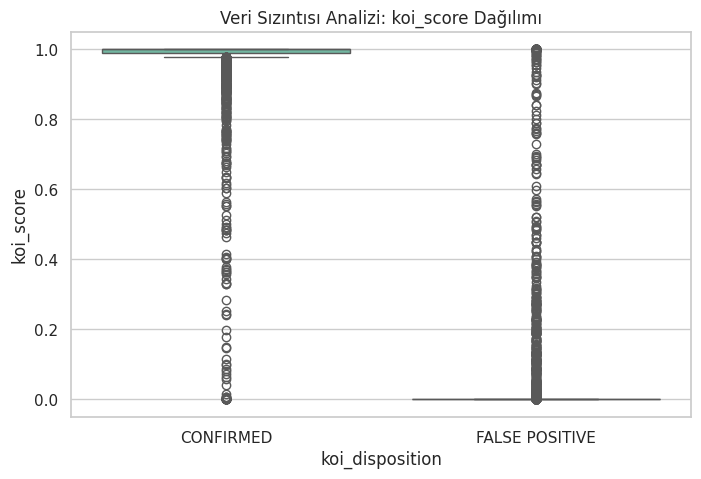

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x='koi_disposition', y='koi_score', data=df, palette='Set2')
plt.title('Veri Sızıntısı Analizi: koi_score Dağılımı')
plt.savefig('koi_score_leakage.png', dpi=300, bbox_inches='tight')

<Figure size 600x500 with 0 Axes>

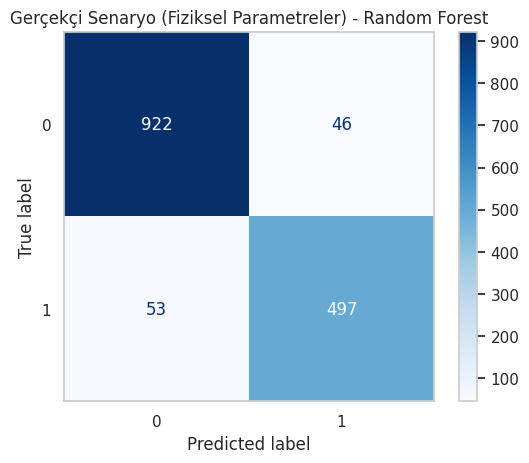

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Gerçekçi senaryo Random Forest modelini eğit
rf_gercekci = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_gercekci.fit(X_train, y_train)

# 2. Test seti üzerinde tahmin üret (Eksik olan değişken burada tanımlanıyor)
y_pred_rf_gercekci = rf_gercekci.predict(X_test)

# 3. Hata Matrisini (Confusion Matrix) çizdir ve kaydet
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_gercekci, cmap='Blues')
plt.title('Gerçekçi Senaryo (Fiziksel Parametreler) - Random Forest')
plt.grid(False)
plt.savefig('confusion_matrix_gercekci.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files
files.download('cm_A_naif_leaky_RandomForest.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('cm_B_gercekci_RandomForest.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>